# Functions

In [4]:
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from geopy.distance import distance
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely.geometry as sg
import matplotlib.pyplot as plt
from shapely import wkt


def utm_string_generator(longitude: float, latitude: float):
    """
    Converts projection string from longitude/latitude (WGS84) to equivalent UTM

    Parameters
    ----------
    longitude: float
        Longitude coordinate
    latitude: float
        Latitude coordinate
        
    Returns
    -------
    str
        EPSG code string for the UTM projection
    """
    # Calculate UTM band value
    utm_value = str((np.floor((longitude + 180) / 6) % 60 + 1).astype(int))

    # Construct string to create equivalent EPSG code
    if len(utm_value) == 1:
        utm_value = "0" + utm_value

    if latitude >= 0.0:
        epsg = "326" + utm_value
    else:
        epsg = "327" + utm_value

    return epsg

def create_boundary_gdf(bounds, projection="epsg:4326"):
    """
    Create a GeoDataFrame for the boundary rectangle from coordinate bounds
    
    Parameters
    ----------
    bounds : dict
        Dictionary with 'latitude' and 'longitude' keys, each containing [min, max]
    projection : str, default="epsg:4326"
        CRS projection string
        
    Returns
    -------
    tuple
        (boundary_gdf, boundary_gdf_utm, utm_num)
    """
    # Get boundary coordinates
    x = bounds["longitude"]
    y = bounds["latitude"]
    
    # Create DataFrame with box corners
    boundary_df = pd.DataFrame(
        {
            "x": np.array([np.min(x), np.max(x), np.max(x), np.min(x), np.min(x)]),
            "y": np.array([np.min(y), np.min(y), np.max(y), np.max(y), np.min(y)]),
        }
    )

    # Create GeoDataFrame
    boundary_gdf = gpd.GeoDataFrame(
        data=boundary_df,
        geometry=gpd.points_from_xy(boundary_df["x"], boundary_df["y"]),
        crs=projection,
    )

    # Convert to UTM (decimal degrees to m)
    utm_code = utm_string_generator(
        (boundary_df.x.min() + boundary_df.x.max()) / 2,
        (boundary_df.y.min() + boundary_df.y.max()) / 2,
    )
    utm_num = int(utm_code)
    boundary_gdf_utm = boundary_gdf.to_crs(utm_num)
    
    return boundary_gdf, boundary_gdf_utm, utm_num

def get_resolution_meters(grid_resolution):
    """
    Convert nautical mile resolution to meters
    
    Parameters
    ----------
    grid_resolution : dict
        Dictionary with 'x_distance' and 'y_distance' in nautical miles
        
    Returns
    -------
    dict
        Resolution in meters
    """
    return {key: distance(nautical=dist).meters for key, dist in grid_resolution.items()}

def create_grid_cells(boundary_gdf_utm, x_step, y_step):
    """
    Generate grid cells based on boundary and step sizes
    
    Parameters
    ----------
    boundary_gdf_utm : GeoDataFrame
        Boundary GeoDataFrame in UTM projection
    x_step : float
        Cell width in meters
    y_step : float
        Cell height in meters
        
    Returns
    -------
    GeoDataFrame
        Grid cells with x, y coordinates
    """
    # Get new boundaries
    xmin, ymin, xmax, ymax = boundary_gdf_utm.total_bounds
    
    # Initialize variables
    grid_cells = []
    y_ct = 0
    x_coord = []
    y_coord = []
    
    # Generate grid cells
    for y0 in np.arange(ymin, ymax, y_step):
        y_ct += 1
        x_ct = 0
        for x0 in np.arange(xmin, xmax, x_step):
            x_ct += 1
            # Step forward
            x_coord.append(x_ct)
            y_coord.append(y_ct)
            x1 = x0 - x_step
            y1 = y0 + y_step
            # Append to list
            grid_cells.append(sg.box(x0, y0, x1, y1))

    # Convert to a GeoDataFrame
    cells_gdf = gpd.GeoDataFrame(grid_cells, columns=["geometry"], crs=boundary_gdf_utm.crs)
    cells_gdf.loc[:, "x"] = np.array(x_coord)
    cells_gdf.loc[:, "y"] = np.array(y_coord)
    
    return cells_gdf

def get_coastline(boundary_gdf, resolution='10m', projection="epsg:4326"):
    """
    Get coastline data from cartopy and clip to boundary
    
    Parameters
    ----------
    boundary_gdf : GeoDataFrame
        Boundary GeoDataFrame
    resolution : str, default='10m'
        Cartopy resolution ('10m', '50m', or '110m')
    projection : str, default="epsg:4326"
        CRS projection string
        
    Returns
    -------
    tuple
        (full_coast, clipped_coast_original, boundary_box_unbuffered_gdf)
    """
    # Get original boundaries
    xmin0, ymin0, xmax0, ymax0 = boundary_gdf.total_bounds

    # Create boundary boxes
    boundary_box = sg.box(xmin0 - 5, ymin0 - 5, xmax0 + 5, ymax0 + 5)
    boundary_box_unbuffered = sg.box(xmin0, ymin0, xmax0, ymax0)
    boundary_box_unbuffered_gdf = gpd.GeoDataFrame(
        geometry=[boundary_box_unbuffered], crs=projection
    )

    # Get coastline from cartopy
    coast_feature = cfeature.NaturalEarthFeature(
        'physical', 'land', resolution,
        edgecolor='black', facecolor='none'
    )
    coast_geometries = list(coast_feature.geometries())
    full_coast = gpd.GeoDataFrame(geometry=coast_geometries, crs=projection)
    
    # Clip the coastline
    clipped_coast_original = gpd.clip(
        full_coast, sg.box(xmin0 + 1, ymin0 + 1, xmax0 + 1, ymax0 + 1)
    )
    
    return full_coast, clipped_coast_original, boundary_box_unbuffered_gdf

def clip_grid_with_coastline(cells_gdf, full_coast, utm_code, boundary_box):
    """
    Clip grid cells to remove land areas
    
    Parameters
    ----------
    cells_gdf : GeoDataFrame
        Grid cells
    full_coast : GeoDataFrame
        Coastline data
    utm_code : int
        UTM EPSG code
    boundary_box : Polygon
        Boundary box for clipping
        
    Returns
    -------
    GeoDataFrame
        Coastline clipped to boundary
    """
    # Convert to UTM and clip coastline
    full_coast_utm = full_coast.to_crs(utm_code)
    full_coast_utm = full_coast_utm[~full_coast_utm.is_empty]
    clipped_coast = gpd.clip(full_coast, boundary_box).to_crs(utm_code)
    
    # Clip the grid cells (remove land areas)
    cells_gdf.loc[:, "geometry"] = cells_gdf["geometry"].difference(
        clipped_coast.geometry.union_all()
    )
    
    return clipped_coast


def calculate_cell_areas(cells_gdf, boundary_box_unbuffered_gdf, projection="epsg:4326"):
    """
    Calculate cell areas and convert back to original projection
    
    Parameters
    ----------
    cells_gdf : GeoDataFrame
        Grid cells in UTM projection
    boundary_box_unbuffered_gdf : GeoDataFrame
        Boundary box for clipping
    projection : str, default="epsg:4326"
        Target projection
        
    Returns
    -------
    GeoDataFrame
        Grid cells with areas in square nautical miles
    """
    # Calculate area per cell
    cells_gdf.loc[:, "area"] = cells_gdf.area
    # Convert back to nmi^2 from m^2
    cells_gdf.loc[:, "area"] = cells_gdf.loc[:, "area"] / 1852**2

    # Convert back to original projection and clip
    clipped_cells_latlon = gpd.clip(
        cells_gdf.to_crs(projection), boundary_box_unbuffered_gdf
    ).reset_index(drop=True)
    
    return clipped_cells_latlon

def filter_grid_cells(clipped_cells_latlon, area_threshold=10):
    """
    Filter grid cells based on area and validity
    
    Parameters
    ----------
    clipped_cells_latlon : GeoDataFrame
        Grid cells
    area_threshold : float, default=10
        Minimum area in square nautical miles
        
    Returns
    -------
    GeoDataFrame
        Filtered grid cells
    """
    filtered_cells = clipped_cells_latlon[
        (clipped_cells_latlon["area"] > area_threshold) &
        (clipped_cells_latlon.is_valid) &
        (~clipped_cells_latlon.is_empty)
    ].reset_index(drop=True)
    
    return filtered_cells

def plot_grid(cells_gdf, coastline=None, boundary_gdf=None, figsize=(10, 10)):
    """
    Plot grid cells with optional coastline and boundary
    
    Parameters
    ----------
    cells_gdf : GeoDataFrame
        Grid cells with area column
    coastline : GeoDataFrame, optional
        Coastline data
    boundary_gdf : GeoDataFrame, optional
        Boundary box
    figsize : tuple, default=(10, 10)
        Figure size
        
    Returns
    -------
    tuple
        (fig, ax) matplotlib figure and axes
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot cells with area color
    plot = cells_gdf.plot(
        column="area", 
        ax=ax, 
        legend=False, 
        cmap="viridis", 
        edgecolor='k', 
        linewidth=0.2, 
        markersize=0
    )
    
    # Add colorbar with proper spacing
    cbar = fig.colorbar(plot.get_children()[0], ax=ax, pad=0.02)
    cbar.set_label('Area (nmi²)')
    
    # Plot coastline if provided
    if coastline is not None:
        coastline.plot(
            ax=ax, 
            color='lightgray', 
            edgecolor='black', 
            linewidth=0.5, 
            label='Coastline'
        )
    
    # Plot boundary if provided
    if boundary_gdf is not None:
        # Set plot limits to boundary
        if hasattr(boundary_gdf.geometry.iloc[0], 'bounds'):
            bounds = boundary_gdf.geometry.iloc[0].bounds
            ax.set_xlim(bounds[0], bounds[2])
            ax.set_ylim(bounds[1], bounds[3])
    
    # Add labels and title
    plt.title("Grid Cell Areas (nmi²)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Adjust layout to ensure nothing is cropped
    plt.tight_layout()
    
    return fig, ax

def save_grid(cells_gdf, filepath):
    """
    Save grid cells to CSV file
    
    Parameters
    ----------
    cells_gdf : GeoDataFrame
        Grid cells
    filepath : str
        Output file path (CSV)
    """
    cells_gdf.to_csv(filepath, index=False)

def load_grid_from_csv(filepath, projection="epsg:4326"):
    """
    Load grid cells from CSV file with WKT geometry
    
    Parameters
    ----------
    filepath : str
        Input CSV file path
    projection : str, default="epsg:4326"
        CRS projection string
        
    Returns
    -------
    GeoDataFrame
        Grid cells loaded from file
    """
    df = pd.read_csv(filepath)
    df["geometry"] = df["geometry"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs=projection)
    return gdf


def create_grid_from_bounds(bounds, grid_resolution, projection="epsg:4326", 
                            coastline_resolution='10m', area_threshold=10):
    """
    Create a complete grid from bounds and resolution
    
    Parameters
    ----------
    bounds : dict
        Dictionary with 'latitude' and 'longitude' keys, each containing [min, max]
    grid_resolution : dict
        Dictionary with 'x_distance' and 'y_distance' in nautical miles
    projection : str, default="epsg:4326"
        CRS projection string
    coastline_resolution : str, default='10m'
        Cartopy resolution ('10m', '50m', or '110m')
    area_threshold : float, default=10
        Minimum area in square nautical miles
        
    Returns
    -------
    tuple
        (clipped_cells_latlon, coastline_clipped, boundary_box_unbuffered_gdf)
    """
    # Create boundary and convert to UTM
    boundary_gdf, boundary_gdf_utm, utm_code = create_boundary_gdf(bounds, projection)
    
    # Get grid resolution in meters
    resolution_m = get_resolution_meters(grid_resolution)
    x_step = resolution_m["x_distance"]
    y_step = resolution_m["y_distance"]
    
    # Create grid cells
    cells_gdf = create_grid_cells(boundary_gdf_utm, x_step, y_step)
    
    # Get coastline data
    full_coast, clipped_coast_original, boundary_box_unbuffered_gdf = get_coastline(
        boundary_gdf, coastline_resolution, projection
    )
    
    # Create boundary box for clipping
    xmin0, ymin0, xmax0, ymax0 = boundary_gdf.total_bounds
    boundary_box = sg.box(xmin0 - 5, ymin0 - 5, xmax0 + 5, ymax0 + 5)
    
    # Clip grid with coastline
    coastline_clipped = clip_grid_with_coastline(cells_gdf, full_coast, utm_code, boundary_box)
    
    # Calculate areas and convert back to lat/lon
    clipped_cells_latlon = calculate_cell_areas(cells_gdf, boundary_box_unbuffered_gdf, projection)
    
    # Filter small or invalid cells
    if area_threshold > 0:
        clipped_cells_latlon = filter_grid_cells(clipped_cells_latlon, area_threshold)
    
    return clipped_cells_latlon, coastline_clipped, boundary_box_unbuffered_gdf

# Generate grid

In [5]:
# Define grid boundary via longitude and latitude coordinates [minimum, maximum]
bounds = {
    "latitude": [32.75, 55.50],
    "longitude": [-135.25, -117.00]
}

# Define grid the resolution in the x- and y-directions in units nmi
grid_resolution = {
    "x_distance": 25.0,
    "y_distance": 25.0
}

# Define EPSG coordinate projection (latitude/longitude)
projection = "epsg:4326"

# Create the full grid
grid_cells, coastline, boundary = create_grid_from_bounds(
    bounds=bounds, 
    grid_resolution=grid_resolution,
    projection=projection,
    coastline_resolution="10m",
    area_threshold=5
)

# Plot grid

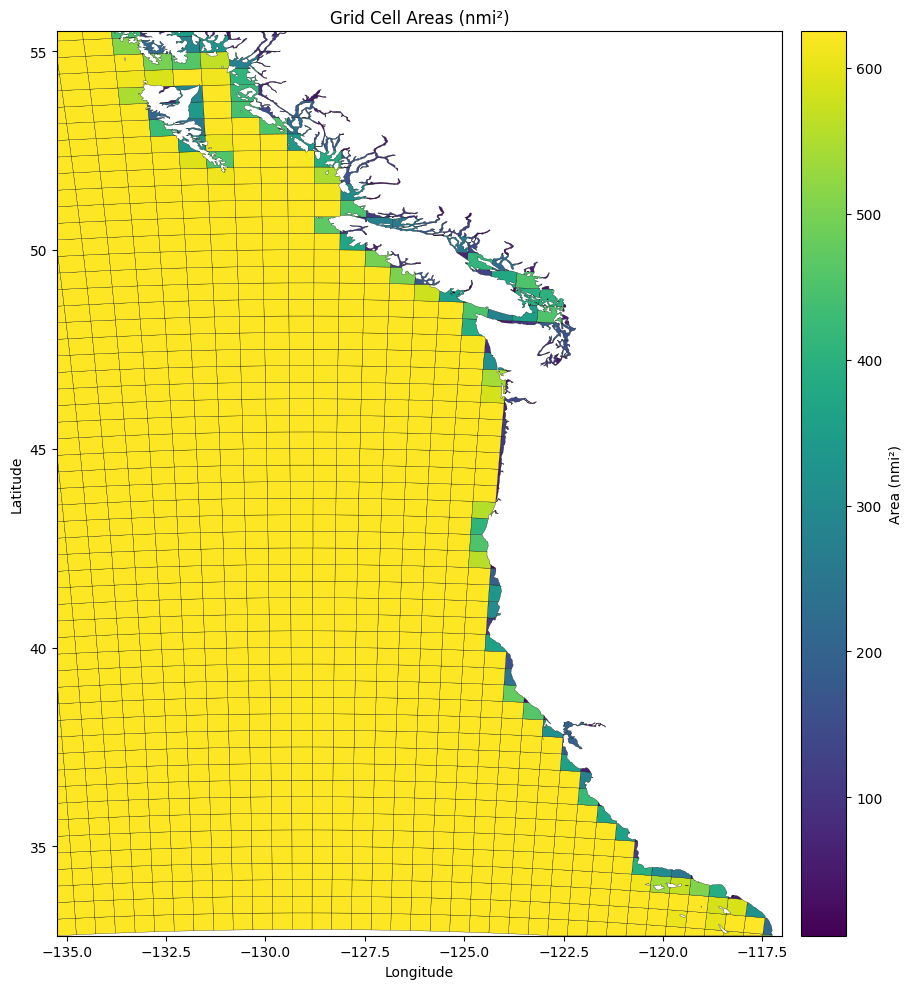

In [6]:
# Plot the grid
fig, ax = plot_grid(grid_cells, coastline, boundary)
plt.show()

# Write and Read Grid `*.csv`

In [7]:
# Write a *.csv file
# ---- This formats the polygon geometries as POLYGON nodes in a WKT format
save_grid(grid_cells, "C:/Users/Brandyn/Documents/example_grid.csv")

# Read in the *.csv file
loaded_grid = load_grid_from_csv("C:/Users/Brandyn/Documents/example_grid.csv", 
                                 projection=projection)


In [8]:
loaded_grid

,geometry,x,y,area
0,"POLYGON ((-117.25452 32.76713, -117.25388 32.7...",38,1,491.943240
1,"POLYGON ((-117.4894 32.78924, -117.49448 32.75...",37,1,625.000000
2,"POLYGON ((-118.44992 32.81882, -118.43837 32.8...",36,1,610.460377
3,"POLYGON ((-118.51361 32.88037, -118.5086 32.87...",35,1,620.304729
4,"POLYGON ((-118.94753 32.9164, -118.96635 32.75...",34,1,625.000000
...,...,...,...,...
1165,"POLYGON ((-135.24446 54.8394, -135.18116 54.42...",5,53,625.000000
1166,"POLYGON ((-134.52703 54.87429, -134.47091 54.4...",6,53,625.000000
1167,"POLYGON ((-135.24446 54.8394, -135.25 54.83909...",5,54,625.000000
1168,"POLYGON ((-134.58461 55.2884, -134.52703 54.87...",6,54,625.000000


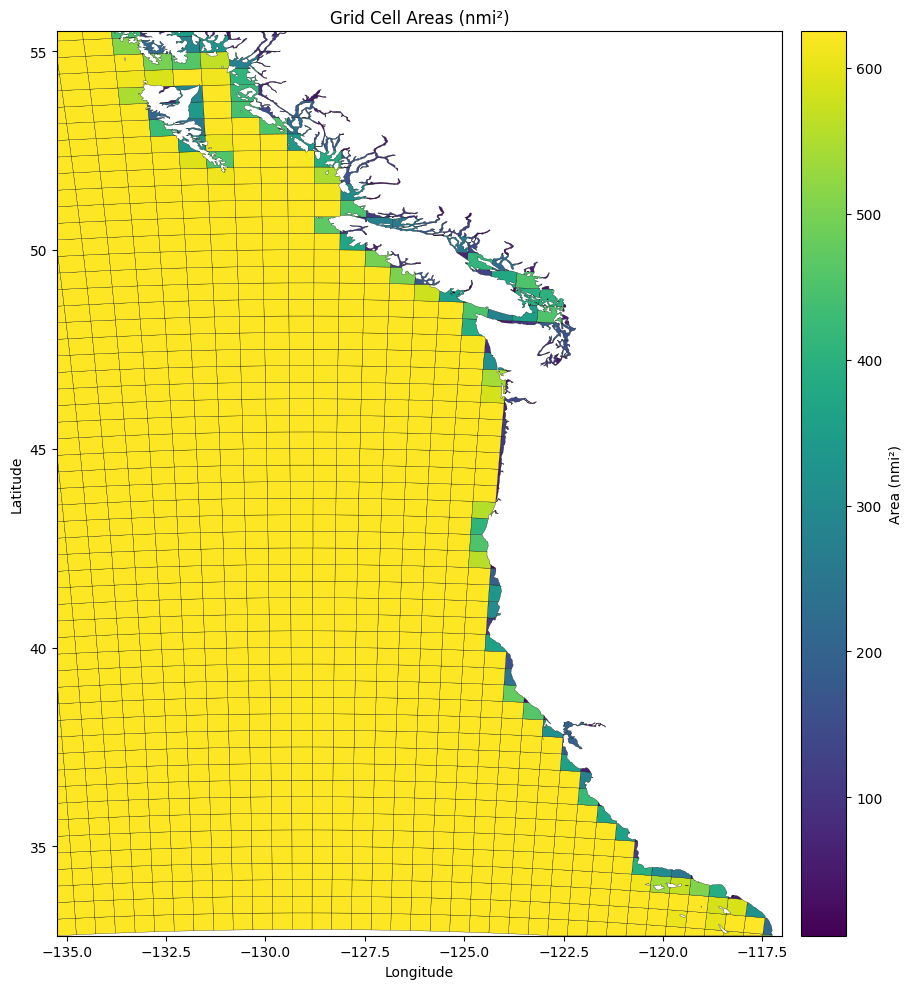

In [9]:
# Plot the loaded grid
fig, ax = plot_grid(loaded_grid, coastline, boundary)
plt.show()